# Parallelization Workflow

## Application
**UPSC Essay Evaluation**

### Input
- Essay

### Parallel Evaluation

#### LLM 1 – Clarity of Thought
- **Output:**
  - Text Feedback (TF)
  - Score (0–10)

#### LLM 2 – Depth of Analysis
- **Output:**
  - Text Feedback (TF)
  - Score (0–10)

#### LLM 3 – Language
- **Output:**
  - Text Feedback (TF)
  - Score (0–10)

### Final Evaluation (LLM 4)

**Inputs:**
- Text Feedback from LLM 1
- Text Feedback from LLM 2
- Text Feedback from LLM 3
- Scores from LLM 1, LLM 2, and LLM 3

**Outputs:**
1. Summarized Feedback
2. Average Final Score

## Workflow

```text
                           START
                             |
                           Essay
                             |
        -------------------------------------------------
        |                     |                        |
        |                     |                        |
     LLM 1                 LLM 2                   LLM 3
(Clarity of Thought)  (Depth of Analysis)      (Language)
        |                     |                        |
   TF + Score            TF + Score              TF + Score
        \                     |                        /
         \                    |                       /
          \-------------------|----------------------/
                              |
                       Final Evaluation
                           (LLM 4)
                              |
              -------------------------------
              |                             |
      Summarized Feedback          Average Final Score
                              |
                             END
```


In [17]:
from dotenv import load_dotenv
load_dotenv(
    
)

True

In [18]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from pydantic import BaseModel,Field
import operator

In [19]:
#create llm
# llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash")
from langchain_groq import ChatGroq


llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [20]:
#create structured output ->From LLM (Isase hum restrict kar sakte hai ki llm kaisa output dega)
class EvaluationSchema(BaseModel):
    feedback:str=Field(description="Detail feedback for essay")
    score:int=Field(description="Score the essay out of 0 to 10" ,ge=0 ,le=10)

In [21]:
#to get structured output
structured_model=llm.with_structured_output(EvaluationSchema)


In [22]:
#structured output 
#structured_model.invoke("""
# Topic: “Education is the key to success.”

# Education plays an important role in a person's life. It gives us knowledge and helps us understand the world. A good education can provide better job opportunities and improve our standard of living.

# However, education is not only about getting marks or degrees. It should also teach discipline, values, critical thinking and responsibility. A person with a degree but without practical knowledge may face difficulties in real life.

# In India, education has improved significantly, but many students still face problems such as poverty, lack of digital access and poor infrastructure. Rural students especially may not get the same opportunities as students in cities.

# Technology can help solve some of these problems by providing online classes and learning resources. But technology alone cannot replace good teachers and proper educational institutions.

# Therefore, education is certainly an important key to success, but success also depends on hard work, skills, opportunities and determination. A balanced education can help individuals as well as society progress.


# """).feedback


In [23]:
#Create State
class UPSCstate(TypedDict):
    essay:str

    cot_tf:str #clearity of thought text feedback
    doa_tf:str #depth of analysis text feedback
    language_tf:str #language text feedback


    final_summary:str
    individual_score:Annotated[list[int],operator.add] #reducer to append  or merge the scores not for replace the score
    avg_score:float


In [24]:
def cot(state:UPSCstate): #clearity of thought node
    
    prompt=f"Evaluate the clearity of thought of the following essay and provide a feedback and assign a score out of 10 :\n{state['essay']}"
    output=structured_model.invoke(prompt)
    return {"cot_tf":output.feedback ,"individual_score":[output.score]}

In [25]:
def doa(state:UPSCstate): #deapth of analysis node
    
    prompt=f"Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 :\n{state['essay']}"
    output=structured_model.invoke(prompt)
    return {"doa_tf":output.feedback,"individual_score":[output.score]}

In [26]:
def language(state:UPSCstate): #Language Understanding syntax grammer etc node
    
    prompt=f"Evaluate the Language Understanding of the following essay and provide a feedback and assign a score out of 10 :\n{state['essay']}"
    output=structured_model.invoke(prompt)
    return {"language_tf":output.feedback,"individual_score":[output.score]}

In [27]:
def final_feedback(state:UPSCstate):
    #summary feedback
    prompt=f"Based on the following feedback create summarized feedback \n language_feedback-{state['language_tf'] } \n Clearity_of_thought feedback-{state['cot_tf']}  \n depth_of_analyss feedback-{state['doa_tf']}"
    overall_feedback=llm.invoke(prompt).content
    #avg calculate
    avg_score=sum(state['individual_score'])/len(state['individual_score'])

    return {"final_summary":overall_feedback,"avg_score":avg_score}


In [28]:
# Create StateGraph
graph = StateGraph(UPSCstate)

# Add nodes
graph.add_node("cot", cot)
graph.add_node("doa", doa)
graph.add_node("language", language)
graph.add_node("final_feedback", final_feedback)

# START -> Parallel evaluation nodes
graph.add_edge(START, "cot")
graph.add_edge(START, "doa")
graph.add_edge(START, "language")

# Parallel nodes -> Final evaluation
graph.add_edge("cot", "final_feedback")
graph.add_edge("doa", "final_feedback")
graph.add_edge("language", "final_feedback")

# Final -> END
graph.add_edge("final_feedback", END)

# Compile
workflow = graph.compile()

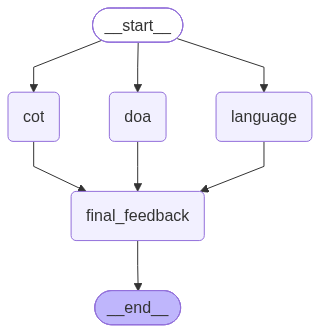

In [29]:
from IPython.display import Image, display

display(
    Image(workflow.get_graph().draw_mermaid_png())
)

In [30]:
essay="""Topic: “Education is the key to success.”

Education plays an important role in a person's life. It gives us knowledge and helps us understand the world. A good education can provide better job opportunities and improve our standard of living.

However, education is not only about getting marks or degrees. It should also teach discipline, values, critical thinking and responsibility. A person with a degree but without practical knowledge may face difficulties in real life.

In India, education has improved significantly, but many students still face problems such as poverty, lack of digital access and poor infrastructure. Rural students especially may not get the same opportunities as students in cities.

Technology can help solve some of these problems by providing online classes and learning resources. But technology alone cannot replace good teachers and proper educational institutions.

Therefore, education is certainly an important key to success, but success also depends on hard work, skills, opportunities and determination. A balanced education can help individuals as well as society progress.


"""


In [31]:
initial_state = {
    "essay":essay
}

In [32]:


output=workflow.invoke(initial_state)

In [33]:
output

{'essay': "Topic: “Education is the key to success.”\n\nEducation plays an important role in a person's life. It gives us knowledge and helps us understand the world. A good education can provide better job opportunities and improve our standard of living.\n\nHowever, education is not only about getting marks or degrees. It should also teach discipline, values, critical thinking and responsibility. A person with a degree but without practical knowledge may face difficulties in real life.\n\nIn India, education has improved significantly, but many students still face problems such as poverty, lack of digital access and poor infrastructure. Rural students especially may not get the same opportunities as students in cities.\n\nTechnology can help solve some of these problems by providing online classes and learning resources. But technology alone cannot replace good teachers and proper educational institutions.\n\nTherefore, education is certainly an important key to success, but success 